# BigAlpha 2026 ML 融合因子

## 因子名称
ML Fusion Factor（机器学习融合因子）

## 核心逻辑
使用 sklearn GradientBoostingRegressor 融合四大数据源：

### 数据源与特征
| 数据源 | 特征数 | 覆盖维度 |
|--------|--------|----------|
| factorlib 因子库 | 14维 | 动量/反转/价值/质量/资金流/波动 |
| bar1m 微观结构 | 12维 | OBI/VWAP/Amihud/价差/深度/反转 |
| financial 财务 | 8维 | DuPont(ROA/利润率/周转率/杠杆/增长) |
| exposure Barra | 10维 | SIZE/BETA/MOMENTUM/RESVOL/... |

### 训练配置
- 模型：GradientBoostingRegressor
- 训练期：2023-01-01 ~ 2024-06-30（硬编码）
- 标签：未来 5 日收益率
- 参数：n_estimators=200, max_depth=4, lr=0.05, min_samples_leaf=50
- NaN：每日期截面中位数填充 + StandardScaler 标准化
- 容灾：训练样本不足时自动回退纯截面排名合成

## 防泄漏
- 训练/预测严格按时间切分，无未来信息
- 财务数据 groupby.ffill 到公告日
- 标签严格使用 T+5 数据，特征全部 T 日已知

## 合规说明
- sklearn 内置模型，无外部依赖
- 输出为截面排名归一化到 [0,1]
- 训练期硬编码，预测期由平台传入

## 输出格式
date / instrument / factor（归一化到[0,1]）


In [1]:
def main(datasources, start_date, end_date):
    """
    ML 融合因子：四数据源 45+ 特征 → GradientBoosting 训练 → 预测

    架构：
    - 训练期（硬编码）：2023-01-01 到 2024-06-30（18个月）
    - 预测期：start_date 到 end_date（平台传入）
    - 标签：未来 5 日收益率
    - 模型：sklearn GradientBoostingRegressor（内置，无外部依赖）

    数据源：
    A. bigalpha_2026_factorlib  14维 —— 动量/反转/价值/质量/资金流
    B. bar1m 微观结构           12维 —— OBI/VWAP/Amihud/价差
    C. bigalpha_2026_financial   8维 —— DuPont 分解
    D. bigalpha_2026_exposure   10维 —— Barra 风格因子

    防泄漏：
    - 训练/预测严格按时间切分
    - 标签 = T+5 未来收益，特征 = T 日已知数据
    - 财务数据 ffill 到公告日
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import structlog
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import GradientBoostingRegressor

    logger = structlog.get_logger()
    t0 = time.time()

    # ============================================================
    # 0. 硬编码
    # ============================================================
    TRAIN_START = '2023-01-01'
    TRAIN_END   = '2024-06-30'
    FORWARD_DAYS = 5
    bar1m_table = datasources["bar1m"]
    fin_table = datasources["financial"]
    eps = 1e-8

    pre_start = str(pd.to_datetime(TRAIN_START) - pd.Timedelta(days=60))
    post_end  = str(pd.to_datetime(end_date) + pd.Timedelta(days=15))

    # ============================================================
    # 1. 因子库（14维）
    # ============================================================
    t1 = time.time()
    flib = dai.query("""
    SELECT date, instrument,
        momentum_5, reversal_5, volatility_5,
        turn, total_market_cap, pe_ttm, pb,
        rsi_12, beta_000300SH_22,
        netflow_amount_rate_main,
        roe_avg_ttm, gross_profit_rate_ttm,
        debt_to_asset_lf, current_ratio_lf
    FROM bigalpha_2026_factorlib
    """, filters={'date': [pre_start, post_end]}, compression=True).df()
    flib['date'] = pd.to_datetime(flib['date'])
    flib['instrument'] = flib['instrument'].astype(str)
    fl_cols = ['momentum_5','reversal_5','volatility_5','turn','total_market_cap',
               'pe_ttm','pb','rsi_12','beta_000300SH_22',
               'netflow_amount_rate_main','roe_avg_ttm','gross_profit_rate_ttm',
               'debt_to_asset_lf','current_ratio_lf']
    for c in fl_cols:
        if c in flib.columns:
            flib[c] = pd.to_numeric(flib[c], errors='coerce')
    flib = flib.replace([np.inf, -np.inf], np.nan)
    flib['earnings_yield'] = np.where(flib['pe_ttm']>0, 1.0/flib['pe_ttm'], np.nan)
    flib['book_to_market'] = np.where(flib['pb']>0, 1.0/flib['pb'], np.nan)
    logger.info("[1/4] 因子库", rows=len(flib), elapsed=round(time.time()-t1,2))

    # ============================================================
    # 2. Barra 暴露（10维）
    # ============================================================
    t2 = time.time()
    exposure = dai.query("""
    SELECT date, instrument,
        SIZE, BETA, MOMENTUM, RESVOL, SIZENL, BTOP,
        LIQUIDTY, EARNYILD, GROWTH, LEVERAGE
    FROM bigalpha_2026_exposure
    """, filters={'date': [pre_start, post_end]}, compression=True).df()
    exposure['date'] = pd.to_datetime(exposure['date'])
    exposure['instrument'] = exposure['instrument'].astype(str)
    barra_cols = ['SIZE','BETA','MOMENTUM','RESVOL','SIZENL','BTOP',
                  'LIQUIDTY','EARNYILD','GROWTH','LEVERAGE']
    for c in barra_cols:
        if c in exposure.columns:
            exposure[c] = pd.to_numeric(exposure[c], errors='coerce')
    logger.info("[2/4] Barra", rows=len(exposure), elapsed=round(time.time()-t2,2))

    # ============================================================
    # 3. 财务 DuPont（8维）
    # ============================================================
    t3 = time.time()
    fin = dai.query(f"""
    SELECT date, instrument,
        net_profit_to_parent_shareholders,
        total_equity_to_parent_shareholders,
        total_liabilities, total_assets,
        gross_profit, operating_revenue,
        total_current_assets, total_current_liabilities
    FROM {fin_table}
    WHERE category='lf' AND shift=0
    """, filters={'date': [pre_start, post_end]}, compression=True).df()
    fin['date'] = pd.to_datetime(fin['date'])
    fin['instrument'] = fin['instrument'].astype(str)
    fin_cols = ['net_profit_to_parent_shareholders','total_equity_to_parent_shareholders',
                'total_liabilities','total_assets','gross_profit','operating_revenue',
                'total_current_assets','total_current_liabilities']
    for c in fin_cols:
        fin[c] = pd.to_numeric(fin[c], errors='coerce')

    all_dates = pd.date_range(pre_start, post_end)
    instruments = sorted(fin['instrument'].dropna().unique())
    full_grid = pd.DataFrame(
        [{'date': d, 'instrument': i} for i in instruments for d in all_dates])
    fin = full_grid.merge(fin, on=['date','instrument'], how='left')
    fin = fin.sort_values(['instrument','date']).reset_index(drop=True)
    fin = fin.set_index(['instrument','date'])
    fin[fin_cols] = fin.groupby('instrument')[fin_cols].ffill()
    fin = fin.reset_index()

    fin['roa'] = np.where(fin['total_assets']>0,
        fin['net_profit_to_parent_shareholders']/fin['total_assets'], np.nan)
    fin['net_margin'] = np.where(fin['operating_revenue']>0,
        fin['net_profit_to_parent_shareholders']/fin['operating_revenue'], np.nan)
    fin['gross_margin'] = np.where(fin['operating_revenue']>0,
        fin['gross_profit']/fin['operating_revenue'], np.nan)
    fin['asset_turnover'] = np.where(fin['total_assets']>0,
        fin['operating_revenue']/fin['total_assets'], np.nan)
    fin['equity_multiplier'] = np.where(
        fin['total_equity_to_parent_shareholders']>0,
        fin['total_assets']/fin['total_equity_to_parent_shareholders'], np.nan)
    fin['debt_ratio_fin'] = np.where(fin['total_assets']>0,
        fin['total_liabilities']/fin['total_assets'], np.nan)
    fin['current_ratio_fin'] = np.where(fin['total_current_liabilities']>0,
        fin['total_current_assets']/fin['total_current_liabilities'], np.nan)
    fin = fin.sort_values(['instrument','date'])
    fin['revenue_growth'] = fin.groupby('instrument')['operating_revenue'].transform(
        lambda x: x / x.shift(252) - 1)

    fin = fin[['date','instrument','roa','net_margin','gross_margin',
               'asset_turnover','equity_multiplier','debt_ratio_fin',
               'current_ratio_fin','revenue_growth']]
    fin = fin.replace([np.inf, -np.inf], np.nan)
    logger.info("[3/4] 财务", rows=len(fin), elapsed=round(time.time()-t3,2))

    # ============================================================
    # 4. Bar1m 微观结构（12维）
    # ============================================================
    t4 = time.time()
    sql_bar = f"""
    WITH bar1m_enriched AS (
        SELECT date, instrument,
            date_trunc('day', date)::DATE AS trading_day,
            strftime(date, '%H%M') AS time_min,
            open, high, low, close, volume, amount, pre_close,
            ask_price1, bid_price1,
            COALESCE(ask_volume1,0) AS av1, COALESCE(bid_volume1,0) AS bv1,
            COALESCE(ask_volume2,0) AS av2, COALESCE(bid_volume2,0) AS bv2,
            COALESCE(ask_volume3,0) AS av3, COALESCE(bid_volume3,0) AS bv3,
            COALESCE(ask_volume4,0) AS av4, COALESCE(bid_volume4,0) AS bv4,
            COALESCE(ask_volume5,0) AS av5, COALESCE(bid_volume5,0) AS bv5,
            (bv1*1.0+bv2*0.7408+bv3*0.5488+bv4*0.4066+bv5*0.3012
             -av1*1.0-av2*0.7408-av3*0.5488-av4*0.4066-av5*0.3012)
            /(bv1*1.0+bv2*0.7408+bv3*0.5488+bv4*0.4066+bv5*0.3012
             +av1*1.0+av2*0.7408+av3*0.5488+av4*0.4066+av5*0.3012
             +1e-8) AS obi_weighted,
            (ask_price1-bid_price1)/((ask_price1+bid_price1)/2+1e-8) AS spread,
            bv1/(bv1+av1+1e-8) AS depth_l1,
            CAST(COALESCE(close,0) AS DOUBLE)
                * CAST(COALESCE(volume,0) AS DOUBLE) AS vwap_num,
            CAST(COALESCE(volume,0) AS DOUBLE)
                * CAST(COALESCE(volume,0) AS DOUBLE) AS vol_sq,
            ABS(close/(LAG(close) OVER (
                PARTITION BY instrument, date_trunc('day', date)
                ORDER BY date)) - 1) AS abs_ret
        FROM {bar1m_table}
        WHERE ask_price1>0 AND bid_price1>0
    ),
    daily_agg AS (
        SELECT trading_day, instrument,
            ARG_MIN(open,date) AS open,
            MAX(high) AS high, MIN(low) AS low,
            ARG_MAX(close,date) AS close,
            SUM(volume) AS volume, SUM(amount) AS amount,
            ARG_MIN(pre_close,date) AS pre_close,
            COUNT(*) AS bar_count,
            AVG(obi_weighted) AS obi_mean,
            CASE WHEN COUNT(*)>5 THEN nanstd(obi_weighted) ELSE 0 END AS obi_std,
            MAX(CASE WHEN time_min>='1430' THEN close END) AS tail_price,
            MIN(CASE WHEN time_min<='1030' THEN close END) AS head_price,
            AVG(spread) AS spread_mean,
            AVG(depth_l1) AS depth_l1,
            SUM(vwap_num)/CAST(SUM(volume)+1e-8 AS DOUBLE) AS vwap,
            SUM(vol_sq)/(CAST(SUM(volume) AS DOUBLE)*CAST(SUM(volume) AS DOUBLE)+1e-8)
                AS vol_concentration,
            AVG(CASE WHEN amount>0 THEN abs_ret/amount ELSE NULL END) AS amihud,
            (MAX(high)-MIN(low))/(ARG_MAX(close,date)+1e-8) AS amplitude,
            SUM(CASE WHEN time_min>='1430' THEN volume ELSE 0 END)
                /(SUM(volume)+1e-8) AS tail_volume_ratio
        FROM bar1m_enriched
        GROUP BY trading_day, instrument
        HAVING COUNT(*)>=100
    )
    SELECT CAST(trading_day AS DATETIME) AS date, instrument,
        open, high, low, close, volume, amount, pre_close, bar_count,
        obi_mean, obi_std, tail_price, head_price,
        spread_mean, depth_l1, vwap, vol_concentration,
        amihud, amplitude, tail_volume_ratio
    FROM daily_agg
    """
    price = dai.query(
        sql_bar, filters={'date': [pre_start, post_end]}, compression=True).df()
    price['date'] = pd.to_datetime(price['date'])
    price['instrument'] = price['instrument'].astype(str)
    bar_cols = ['open','high','low','close','volume','amount','pre_close','bar_count',
                'obi_mean','obi_std','tail_price','head_price',
                'spread_mean','depth_l1','vwap','vol_concentration',
                'amihud','amplitude','tail_volume_ratio']
    for c in bar_cols:
        if c in price.columns:
            price[c] = pd.to_numeric(price[c], errors='coerce')
    price = price.replace([np.inf, -np.inf], np.nan)
    logger.info("[4/4] Bar1m", rows=len(price), elapsed=round(time.time()-t4,2))

    # ============================================================
    # 5. 合并 + 衍生特征
    # ============================================================
    t5 = time.time()
    df = pd.merge(flib, price, how='inner', on=['date','instrument'])
    df = pd.merge(df, fin, how='left', on=['date','instrument'])
    barra_use = ['date','instrument'] + [c for c in barra_cols if c in exposure.columns]
    df = pd.merge(df, exposure[barra_use], how='left', on=['date','instrument'])

    df['vwap_gap'] = np.where(
        (df['vwap']>0) & df['vwap'].notna(),
        (df['close']-df['vwap'])/(df['vwap']+eps), np.nan)
    df['intraday_reversal'] = np.where(
        (df['head_price']>0) & df['head_price'].notna(),
        df['tail_price']/df['head_price']-1, np.nan)
    df['price_position'] = np.where(
        (df['high']-df['low'])>eps,
        (df['close']-df['low'])/(df['high']-df['low']+eps), np.nan)
    df['overnight_ret'] = np.where(df['pre_close']>0,
        (df['open']-df['pre_close'])/df['pre_close'], np.nan)
    df['intraday_ret'] = np.where(df['open']>0,
        (df['close']-df['open'])/df['open'], np.nan)

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.sort_values(['instrument','date']).reset_index(drop=True)
    logger.info("合并完成", rows=len(df), elapsed=round(time.time()-t5,2))

    # ============================================================
    # 6. 特征列表
    # ============================================================
    fl_features = ['momentum_5','reversal_5','volatility_5','turn','total_market_cap',
                   'earnings_yield','book_to_market','rsi_12','beta_000300SH_22',
                   'netflow_amount_rate_main','roe_avg_ttm','gross_profit_rate_ttm',
                   'debt_to_asset_lf','current_ratio_lf']
    mi_features = ['obi_mean','obi_std','vwap_gap','intraday_reversal',
                   'vol_concentration','spread_mean','depth_l1','amihud',
                   'amplitude','price_position','tail_volume_ratio',
                   'overnight_ret','intraday_ret','bar_count']
    fi_features = ['roa','net_margin','gross_margin','asset_turnover',
                   'equity_multiplier','debt_ratio_fin','current_ratio_fin',
                   'revenue_growth']
    bx_features = [c for c in barra_cols if c in df.columns]

    feature_cols = fl_features + mi_features + fi_features + bx_features
    feature_cols = [c for c in feature_cols if c in df.columns]

    # ============================================================
    # 7. 标签：T+5 未来收益
    # ============================================================
    t7 = time.time()
    df['close_fwd'] = df.groupby('instrument')['close'].transform(
        lambda x: x.shift(-FORWARD_DAYS))
    df['date_fwd'] = df.groupby('instrument')['date'].transform(
        lambda x: x.shift(-FORWARD_DAYS))
    df['days_gap'] = (df['date_fwd'] - df['date']).dt.days
    df['label'] = np.where(
        (df['days_gap'] <= 10) & (df['close_fwd'] > 0),
        df['close_fwd'] / df['close'] - 1, np.nan)
    df['label'] = df['label'].clip(-0.30, 0.30)
    logger.info("标签完成", elapsed=round(time.time()-t7,2))

    # ============================================================
    # 8. 时间切分
    # ============================================================
    train_st_dt = pd.to_datetime(TRAIN_START)
    train_end_dt = pd.to_datetime(TRAIN_END)
    pred_st_dt = pd.to_datetime(start_date)
    pred_end_dt = pd.to_datetime(end_date)

    train_set = df[(df['date'] >= train_st_dt) & (df['date'] <= train_end_dt)].copy()
    pred_set  = df[(df['date'] >= pred_st_dt) & (df['date'] <= pred_end_dt)].copy()
    train_set = train_set.dropna(subset=['label'])

    logger.info(f"切分: train={len(train_set)} pred={len(pred_set)} features={len(feature_cols)}")

    if len(train_set) < 2000:
        return _fallback(df, pred_set, feature_cols, start_date, end_date)

    # ============================================================
    # 9. NaN填充 + 标准化
    # ============================================================
    t9 = time.time()

    def impute_and_scale(data, feature_list, scaler=None, fit_scaler=False):
        data = data.copy()
        for c in feature_list:
            if c in data.columns:
                data[c] = pd.to_numeric(data[c], errors='coerce')
        data[feature_list] = data[feature_list].replace([np.inf, -np.inf], np.nan)
        data[feature_list] = data.groupby('date')[feature_list].transform(
            lambda x: x.fillna(x.median()))
        data[feature_list] = data[feature_list].fillna(0.0)
        data[feature_list] = data[feature_list].clip(-10, 10)
        X = data[feature_list].values.astype(np.float64)
        if fit_scaler:
            s = StandardScaler()
            X = s.fit_transform(X)
            return X, data, s
        elif scaler is not None:
            X = scaler.transform(X)
            return X, data, scaler
        return X, data, None

    X_train, train_set, scaler = impute_and_scale(train_set, feature_cols, fit_scaler=True)
    y_train = train_set['label'].values.astype(np.float64)
    X_pred, pred_set, _ = impute_and_scale(pred_set, feature_cols, scaler=scaler)

    logger.info(f"预处理: X_train={X_train.shape} X_pred={X_pred.shape}",
                 elapsed=round(time.time()-t9,2))

    # ============================================================
    # 10. 模型训练
    # ============================================================
    t10 = time.time()

    model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        min_samples_leaf=50,
        subsample=0.8,
        random_state=42,
    )
    model.fit(X_train, y_train)

    logger.info(f"GB训练完成: n_estimators={model.n_estimators_}",
                 elapsed=round(time.time()-t10,2))

    # 特征重要性 Top 10
    imp = model.feature_importances_
    imp_order = np.argsort(-imp)[:10]
    logger.info("【特征重要性Top10】")
    for rank, idx in enumerate(imp_order, 1):
        logger.info(f"  {rank:2d}. {feature_cols[idx]:30s} {imp[idx]:.6f}")

    # ============================================================
    # 11. 预测 → 截面排名 → 对齐成分股 → 输出
    # ============================================================
    t11 = time.time()

    y_pred = model.predict(X_pred)
    pred_set = pred_set.copy()
    pred_set['factor_raw'] = y_pred
    pred_set['factor'] = pred_set.groupby('date')['factor_raw'].rank(
        pct=True, na_option='bottom')

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(
        stk_pool, pred_set[['date','instrument','factor']],
        how='left', on=['date','instrument'],
    )
    result['factor'] = pd.to_numeric(result['factor'], errors='coerce')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result['factor'] = result.groupby('date')['factor'].transform(
        lambda x: x.fillna(x.median()))
    result['factor'] = result['factor'].fillna(0.0)

    logger.info("ML融合因子完成", rows=len(result),
                 features=len(feature_cols),
                 elapsed=round(time.time()-t11,2),
                 total=round(time.time()-t0,2))
    return result[['date','instrument','factor']].copy()


def _fallback(df, pred_set, feature_cols, start_date, end_date):
    import numpy as np
    import pandas as pd
    import dai
    pred_set = pred_set.copy()
    all_rank_cols = []
    for fc in feature_cols:
        if fc in pred_set.columns:
            rk = f'r_{fc}'
            pred_set[rk] = pred_set.groupby('date')[fc].rank(pct=True, na_option='bottom')
            all_rank_cols.append(rk)
    pred_set['factor'] = pred_set[all_rank_cols].sum(axis=1) / max(len(all_rank_cols), 1)

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]}).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)
    result = pd.merge(stk_pool, pred_set[['date','instrument','factor']],
                      how='left', on=['date','instrument'])
    result['factor'] = pd.to_numeric(result['factor'], errors='coerce')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result['factor'] = result.groupby('date')['factor'].transform(
        lambda x: x.fillna(x.median()))
    result['factor'] = result['factor'].fillna(0.0)
    return result[['date','instrument','factor']].copy()


[2026-07-07 15:39:10] [info     ] 计算因子，测试区间：2024-07-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-07 15:39:11] [info     ] [1/4] 因子库                      elapsed=0.46 rows=537000
[2026-07-07 15:39:11] [info     ] [2/4] Barra                    elapsed=0.19 rows=536724
[2026-07-07 15:39:20] [info     ] [3/4] 财务                       elapsed=9.11 rows=1828008
[2026-07-07 15:41:09] [info     ] [4/4] Bar1m                    elapsed=109.07 rows=1128662
[2026-07-07 15:41:11] [info     ] 合并完成                           elapsed=2.04 rows=523564
[2026-07-07 15:41:12] [info     ] 标签完成                           elapsed=0.47
[2026-07-07 15:41:12] [info     ] 切分: train=329745 pred=123824 features=46
[2026-07-07 15:41:19] [info     ] 预处理: X_train=(329745, 46) X_pred=(123824, 46) elapsed=7.1
[2026-07-07 16:04:19] [info     ] GB训练完成: n_estimators=200       elapsed=1379.93
[2026-07-07 16:04:19] [info     ] 【特征重要性Top10】
[2026-07-07 16:04:19] [info     ]    1. revenue_growth                 0.224309
[2026-0

时段,IC
2024-09-24~2024-10-08,0.0083

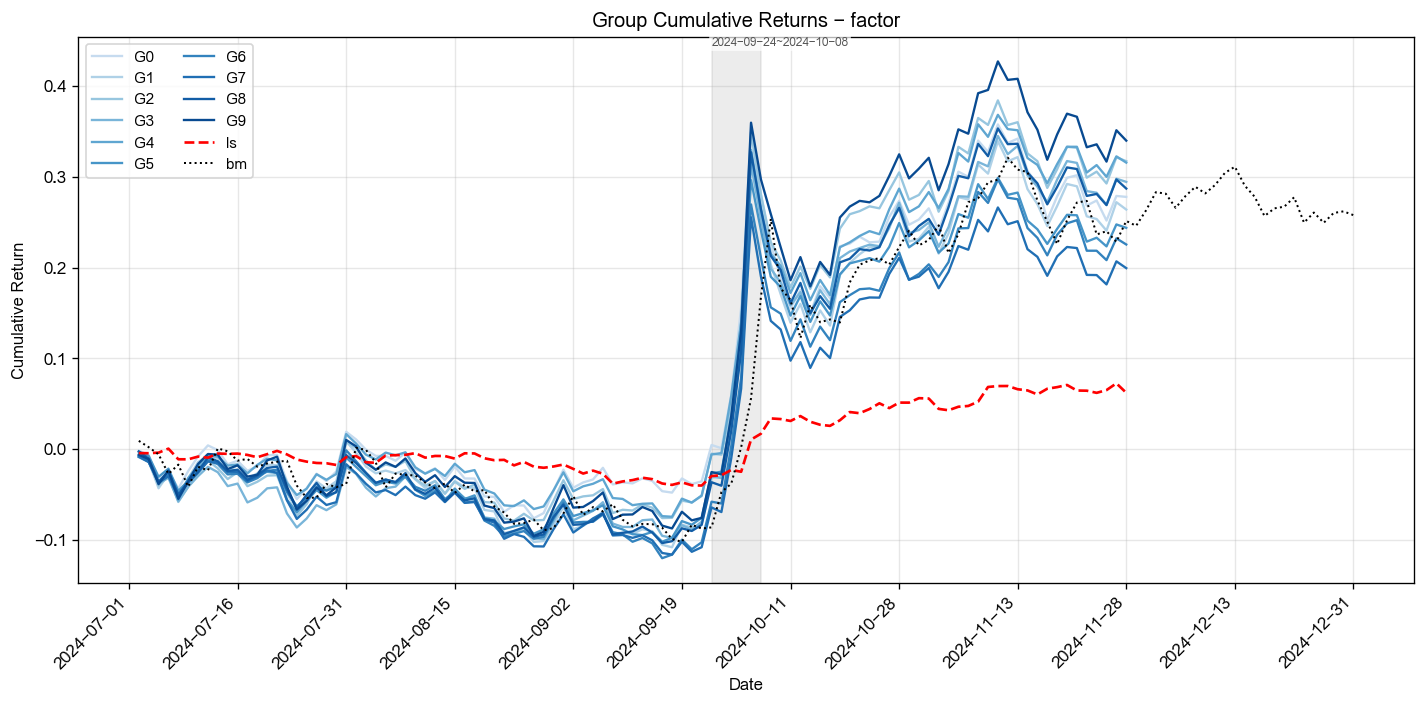
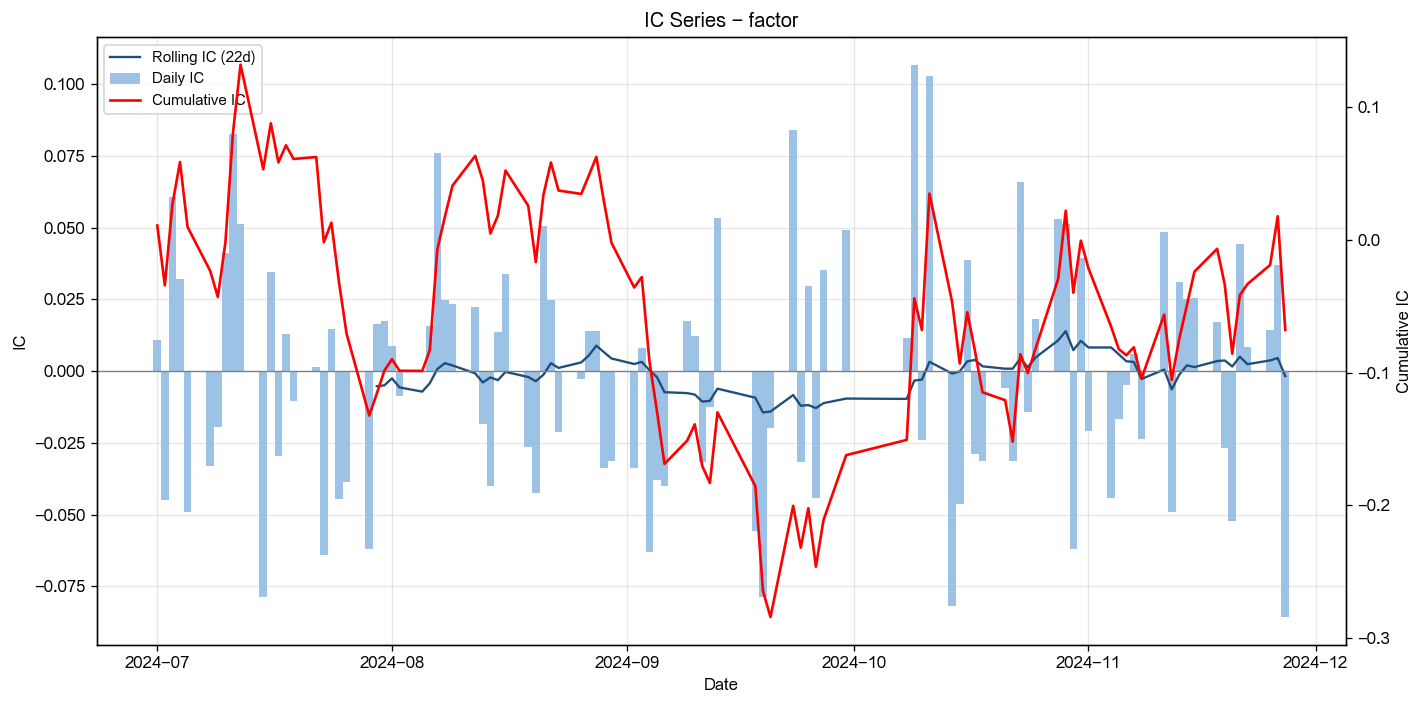
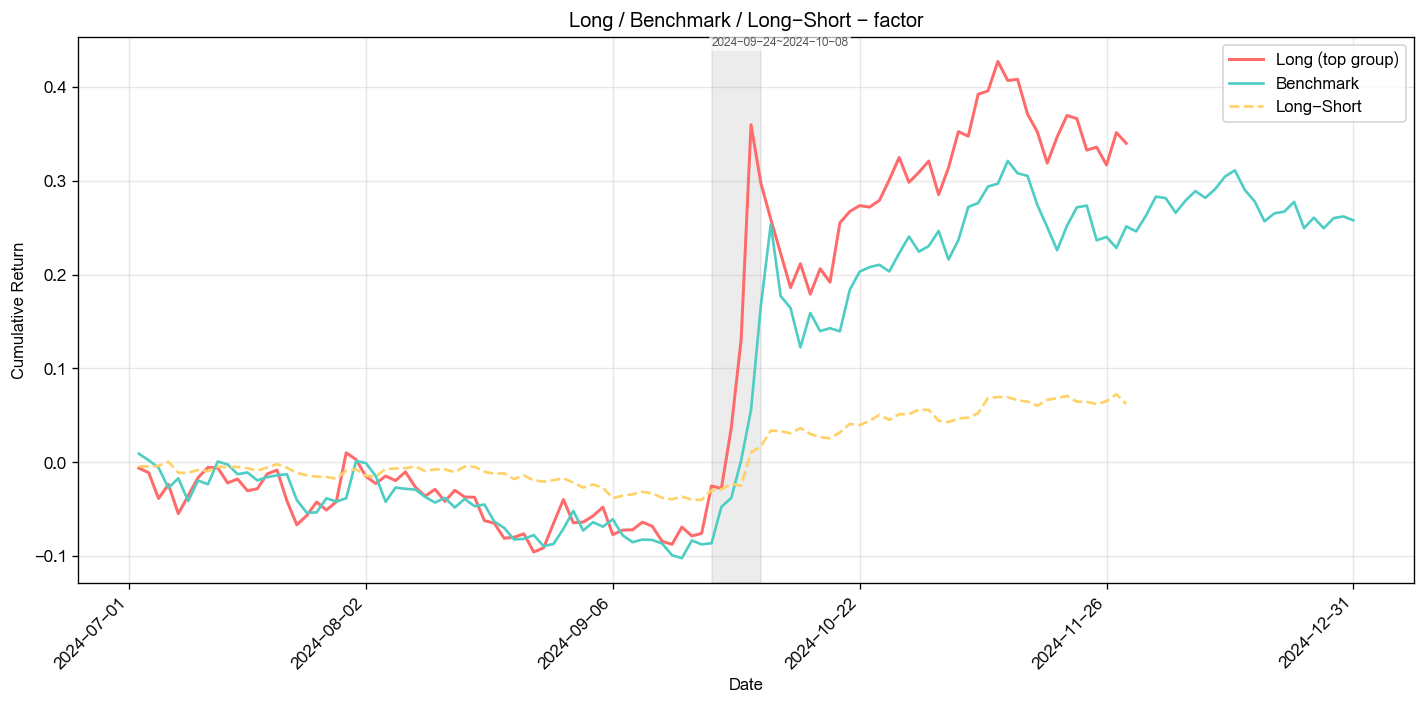
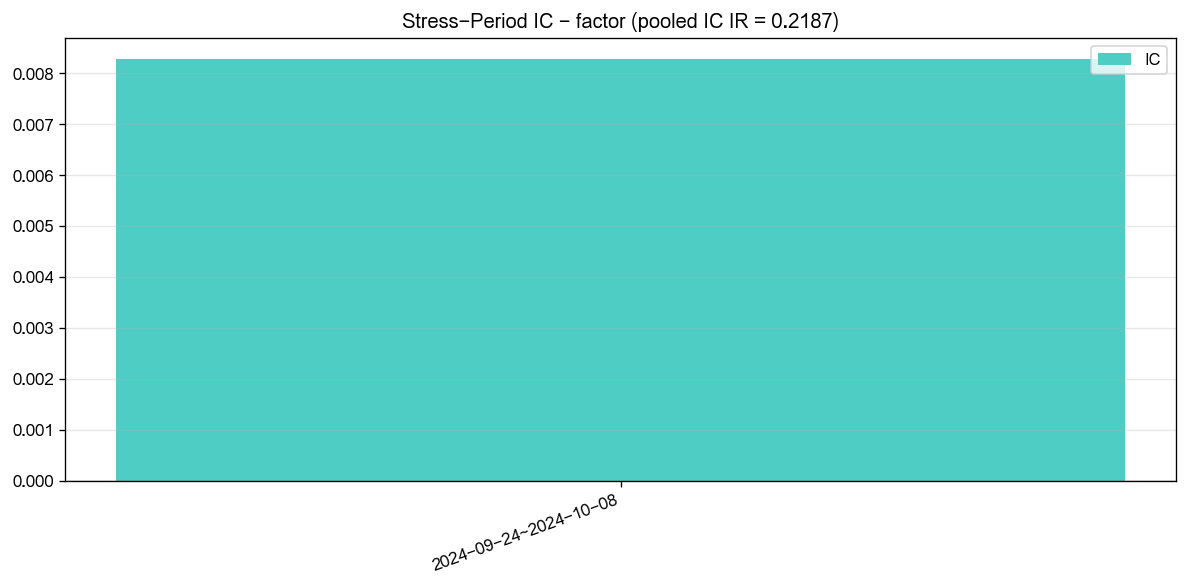
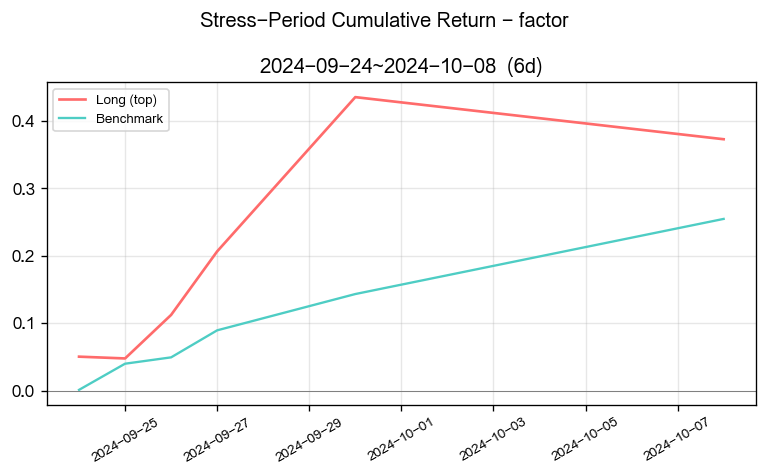

[2026-07-07 16:04:29] [info     ] ========== 因子池回归 ==========
[2026-07-07 16:04:30] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1103 rows=145937 start_date=2024-07-01
[2026-07-07 16:04:30] [info     ] 获取收益率数据, 耗时: 0.8051 秒
[2026-07-07 16:04:30] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.1484 秒
[2026-07-07 16:04:30] [info     ] 统计 回归结果, 耗时: 0.0182 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,cci_14,4.9720,0.0586,0.0118,1.0000
2,ps_ttm,4.4885,0.0048,0.0011,1.0000
3,volume,3.0242,0.0214,0.0071,1.0000
4,macd_hist_12_26_9,2.5406,0.0124,0.0049,1.0000
5,rsi_12,2.5298,0.0540,0.0213,1.0000
6,net_profit_rate_ttm,2.0785,0.0046,0.0022,1.0000
7,netflow_amount_main,2.0407,0.0336,0.0165,1.0000
8,netflow_amount_rate_main,1.9291,0.0168,0.0087,1.0000
9,turn,1.8497,0.0138,0.0074,1.0000
10,total_market_cap,1.8423,0.0177,0.0096,1.0000

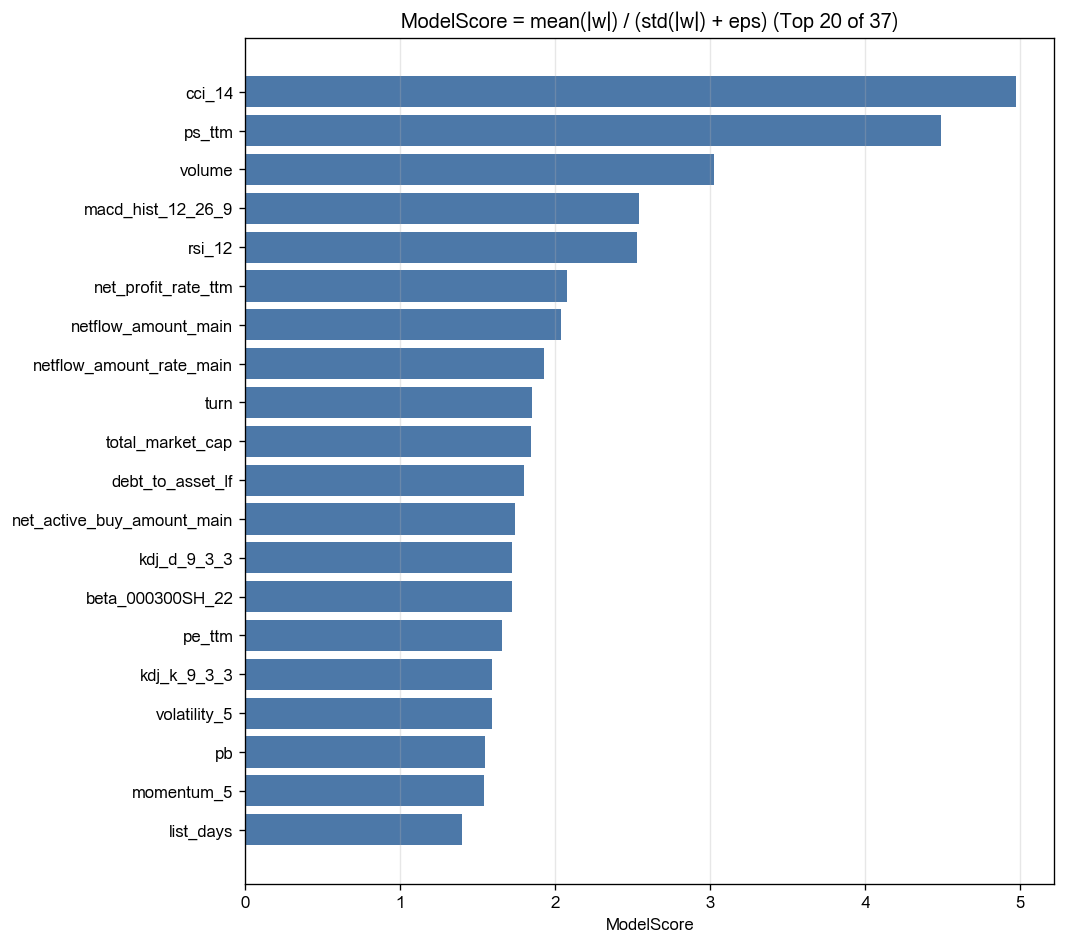
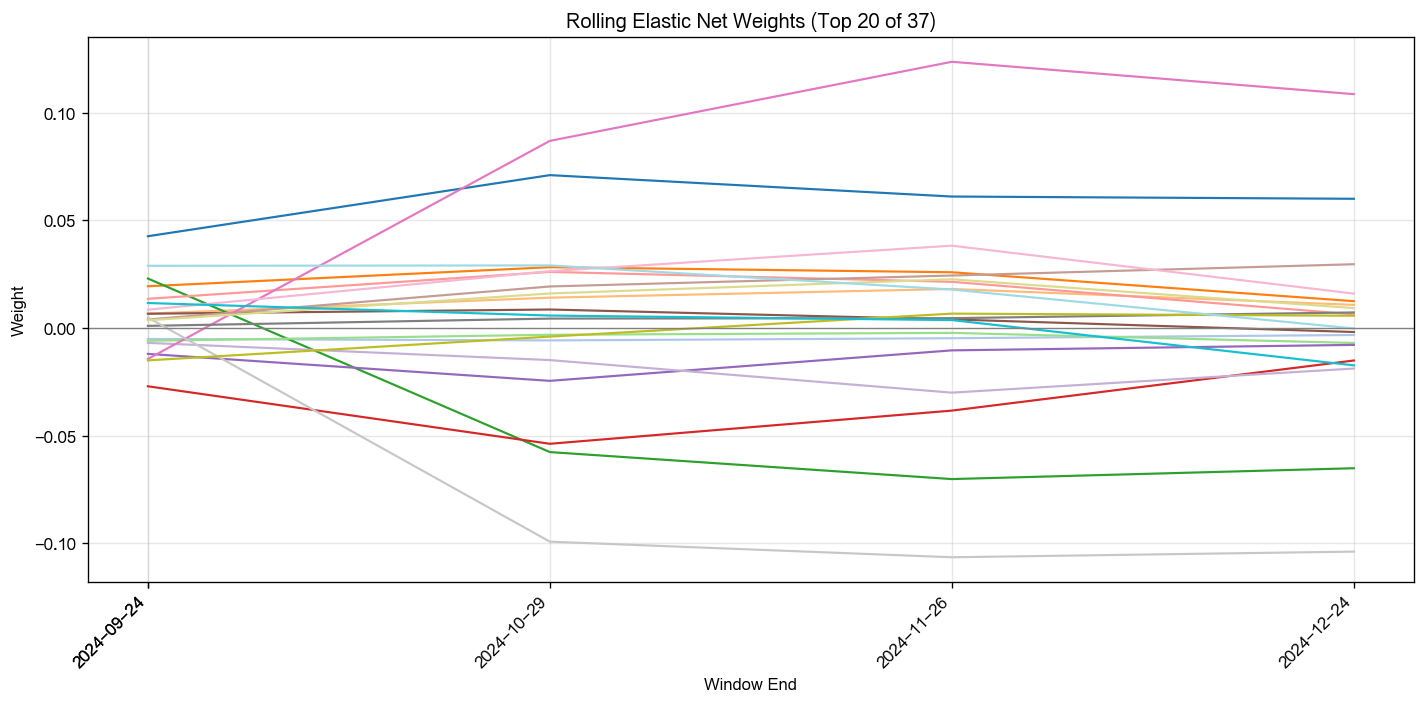
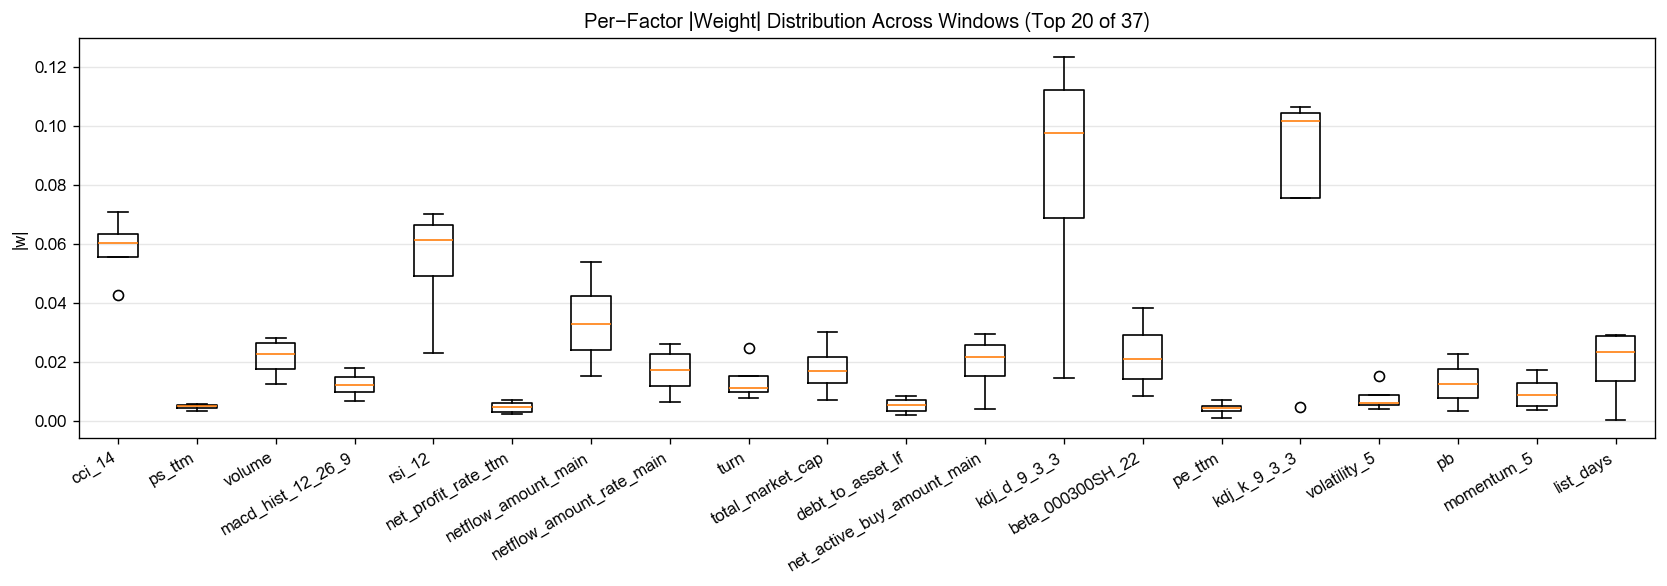
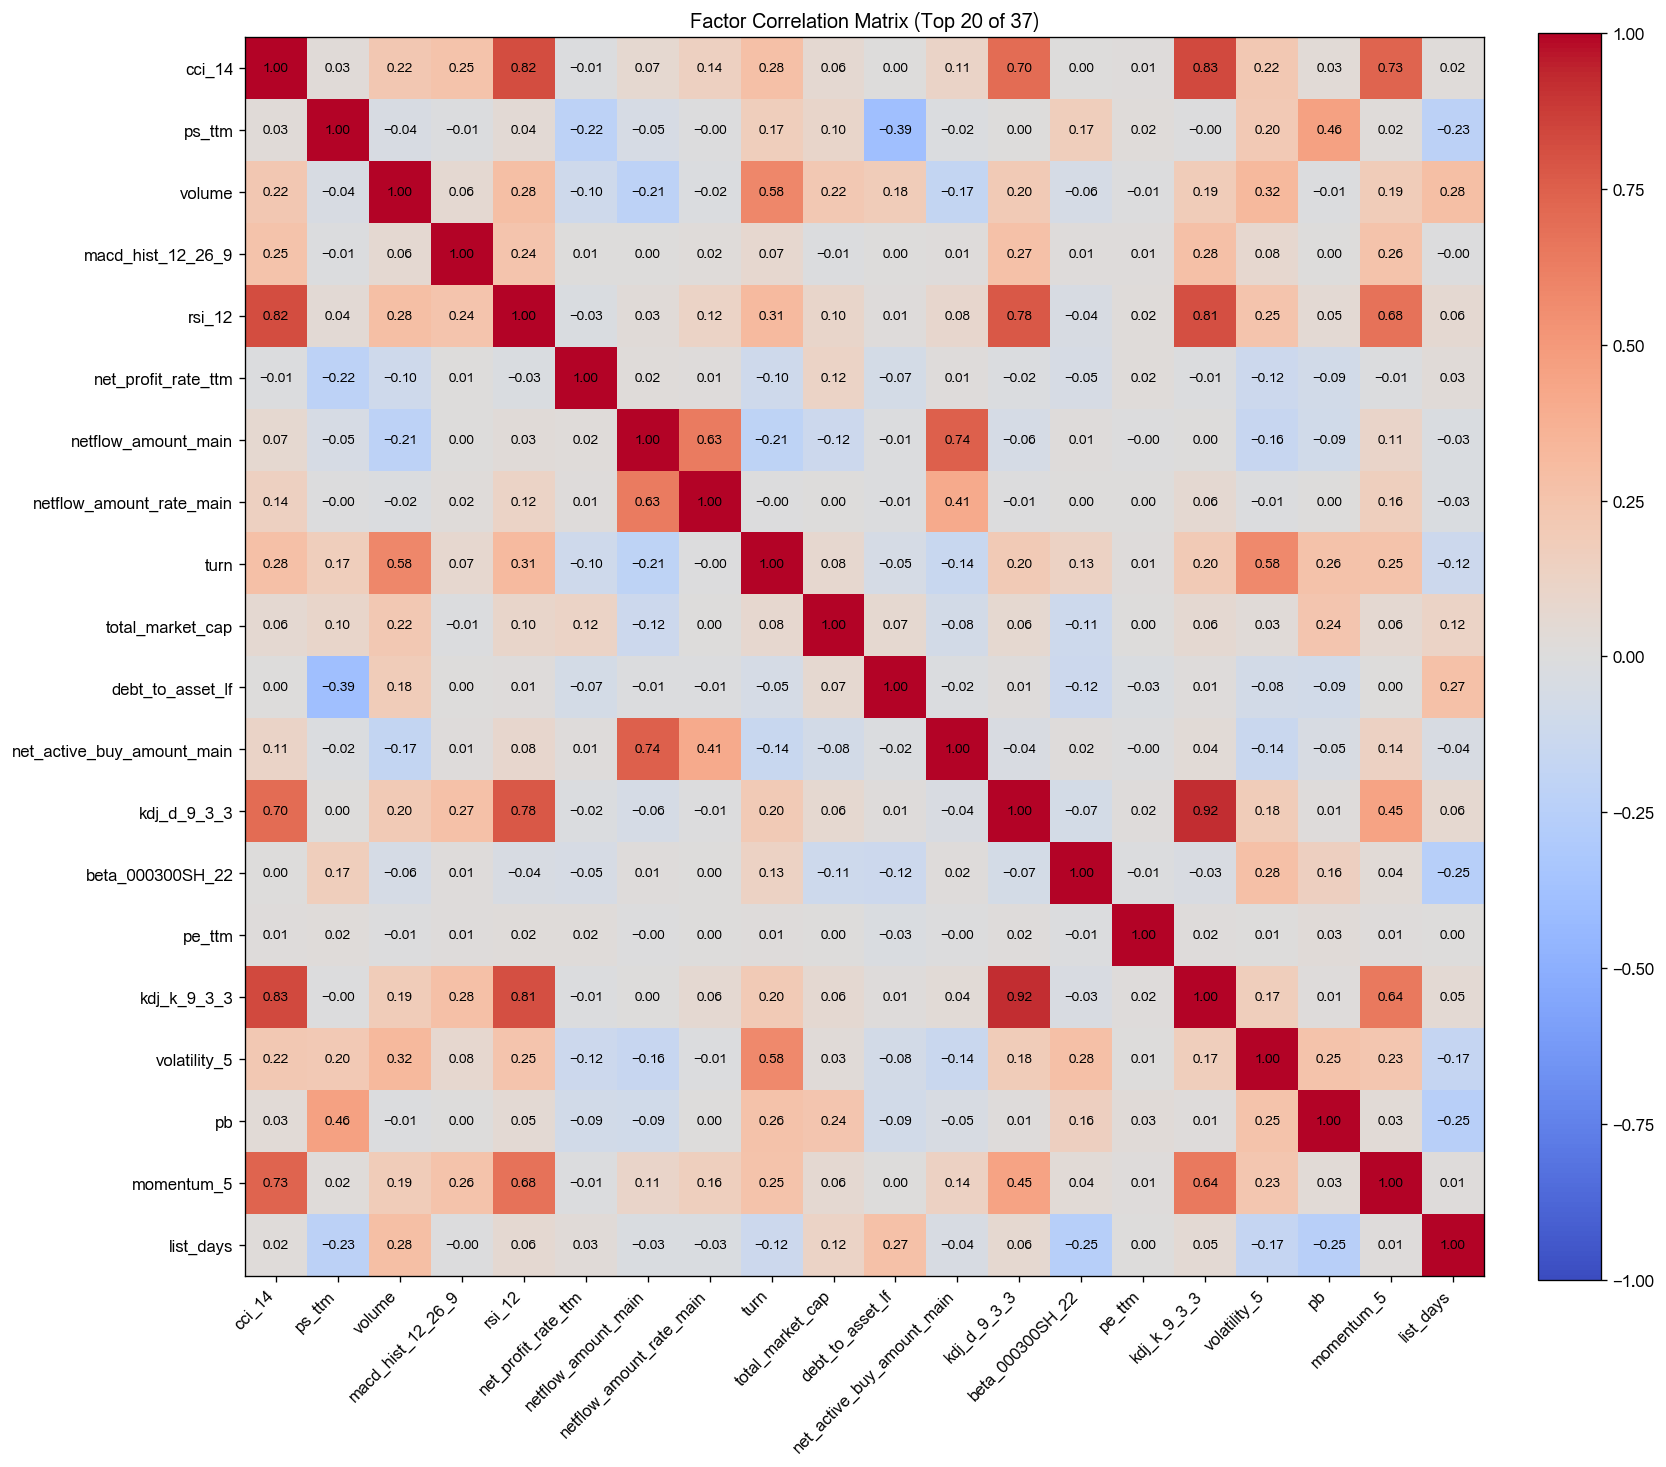

[2026-07-07 16:04:33] [warning  ] 返回的Outputs实例(size=17874531) 大于 64K, 将不会被缓存
[2026-07-07 16:04:33] [info     ] bigalpha_eval.v4 运行完成 [9.741s].


In [2]:
if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial',
    }
    start_date = '2024-07-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
